In [1]:
import numpy as np
import pandas as pd
import os
from sklearn.preprocessing import LabelEncoder

import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import accuracy_score

from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, EarlyStoppingCallback
from datasets import Dataset

c:\Users\mario\Desktop\Deep Learning\Progetto\multimodal-crisis-classification\deep_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from dotenv import load_dotenv
load_dotenv()

True

In [3]:
data_dir = os.getenv("DATA_DIR")
datasplits_dir = os.getenv("DATASPLITS_DIR")
embeddings_dir = os.getenv("EMBEDDINGS_DIR")

text_train_path = os.path.join(datasplits_dir, "text_train.tsv")
text_val_path = os.path.join(datasplits_dir, "text_val.tsv")
text_test_path = os.path.join(datasplits_dir, "text_test.tsv")

train_bert_path = os.path.join(embeddings_dir, "train_bert.npy")
val_bert_path = os.path.join(embeddings_dir, "val_bert.npy")
test_bert_path = os.path.join(embeddings_dir, "test_bert.npy")

train_roberta_path = os.path.join(embeddings_dir, "train_roberta.npy")
val_roberta_path = os.path.join(embeddings_dir, "val_roberta.npy")
test_roberta_path = os.path.join(embeddings_dir, "test_roberta.npy")

train_bertweet_path = os.path.join(embeddings_dir, "train_bertweet.npy")
val_bertweet_path = os.path.join(embeddings_dir, "val_bertweet.npy")
test_bertweet_path = os.path.join(embeddings_dir, "test_bertweet.npy")

In [4]:
train_bert = np.load(train_bert_path)
val_bert = np.load(val_bert_path)
test_bert = np.load(test_bert_path)

train_roberta = np.load(train_roberta_path)
val_roberta = np.load(val_roberta_path)
test_roberta = np.load(test_roberta_path)

train_bertweet = np.load(train_bertweet_path)
val_bertweet = np.load(val_bertweet_path)
test_bertweet = np.load(test_bertweet_path)

In [5]:

text_train_df = pd.read_csv(text_train_path, sep='\t')
text_val_df = pd.read_csv(text_val_path, sep='\t')
text_test_df = pd.read_csv(text_test_path, sep='\t')

print(f"text train set size: {len(text_train_df)}")
print(f"text val set size: {len(text_val_df)}")
print(f"text test set size: {len(text_test_df)}")

text_train_df.head()

text train set size: 11240
text val set size: 2409
text test set size: 2409


,tweet_text,text_info,text_human,cleaned_text_bert,cleaned_text_bertweet
0,Trucking Companies Houston's Lifeline Surges I...,informative,rescue_volunteering_or_donation_effort,Trucking Companies Houston's Lifeline Surges I...,Trucking Companies Houston's Lifeline Surges I...
1,#Hurricane #Harvey damaged #ExxonMobil refiner...,informative,infrastructure_and_utility_damage,Hurricane Harvey damaged ExxonMobil refineries...,#Hurricane #Harvey damaged #ExxonMobil refiner...
2,Witness in former Mora superintendent's forger...,not_informative,not_humanitarian,Witness in former Mora superintendent's forger...,Witness in former Mora superintendent's forger...
3,Mexico earthquake: Many children killed at pri...,informative,affected_individuals,Mexico earthquake: Many children killed at pri...,Mexico earthquake: Many children killed at pri...
4,@KrollOntrack is offering discounted recoverie...,informative,rescue_volunteering_or_donation_effort,is offering discounted recoveries for hurrican...,@KrollOntrack is offering discounted recoverie...


In [6]:
#Task 1: Binary (text_info)
le_info = LabelEncoder()
le_info.fit(text_train_df["text_info"])  # Adatta solo sul train

train_labels_task1 = le_info.transform(text_train_df["text_info"])
val_labels_task1 = le_info.transform(text_val_df["text_info"])
test_labels_task1 = le_info.transform(text_test_df["text_info"])

#Task 2: Multiclasse (text_human)
le_human = LabelEncoder()
le_human.fit(text_train_df["text_human"])

train_labels_task2 = le_human.transform(text_train_df["text_human"])
val_labels_task2 = le_human.transform(text_val_df["text_human"])
test_labels_task2 = le_human.transform(text_test_df["text_human"])

#Mapping classi e label
print("Task 1 classes:", dict(zip(le_info.classes_, le_info.transform(le_info.classes_))))
print("Task 2 classes:", dict(zip(le_human.classes_, le_human.transform(le_human.classes_))))

Task 1 classes: {'informative': np.int64(0), 'not_informative': np.int64(1)}
Task 2 classes: {'affected_individuals': np.int64(0), 'infrastructure_and_utility_damage': np.int64(1), 'not_humanitarian': np.int64(2), 'other_relevant_information': np.int64(3), 'rescue_volunteering_or_donation_effort': np.int64(4)}


In [72]:
def create_mlp(input_dim, output_dim, is_binary):
    
    input = keras.Input(shape=(input_dim,))

    x = layers.Dense(512, activation='relu')(input)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)

    output = layers.Dense(output_dim, activation='sigmoid' if is_binary else 'softmax')(x)
    model = keras.Model(inputs=input, outputs=output)

    model.compile(
        loss='binary_crossentropy' if is_binary else 'categorical_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )
    
    return model

In [73]:
def plot_training_history(history, title="Model Training"):
    """
    Plot accuracy and loss curves for training and validation.

    Parameters:
        history (History): Keras History object returned by model.fit()
        title (str): Title prefix for the plots
    """
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(14, 5))

    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.title(f'{title} - Accuracy')
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.title(f'{title} - Loss')
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.tight_layout()
    plt.show()


In [28]:
def evaluate_task(name, y_test, y_pred_labels, task=1, label_encoder=None):   
    is_binary = (task == 1)
    
    # 📊 Report metriche
    acc = accuracy_score(y_test, y_pred_labels)
    avg_type = 'binary' if is_binary else 'macro'
    prec = precision_score(y_test, y_pred_labels, average=avg_type, zero_division=0)
    rec = recall_score(y_test, y_pred_labels, average=avg_type, zero_division=0)
    f1 = f1_score(y_test, y_pred_labels, average=avg_type, zero_division=0)

    print(f"\n📊 Results for {name.upper()} - Task {task}")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")

    # 🧩 Matrice di confusione
    if label_encoder:
        display_labels = label_encoder.classes_
    else:
        display_labels = None

    cm = confusion_matrix(y_test, y_pred_labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
    disp.plot(cmap='Blues')
    if not is_binary:
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()

    plt.title(f"Confusion Matrix - {name.upper()} - Task {task}", )
    plt.show()

In [ ]:
def train_and_evaluate(name, X_train, y_train, X_val, y_val, X_test, y_test, task=1, label_encoder=None):
    is_binary = (task == 1)
    y_train_enc = y_train if is_binary else to_categorical(y_train)
    y_val_enc = y_val if is_binary else to_categorical(y_val)
    
    model = create_mlp(X_train.shape[1], 1 if is_binary else y_train_enc.shape[1], is_binary)
    print(f"\n🚀 Training MLP on {name.upper()} embeddings (Task {task})")

    es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

    history = model.fit(
        X_train, y_train_enc,
        validation_data=(X_val, y_val_enc),
        epochs=50,
        batch_size=32,
        callbacks=[es],
    )

    plot_training_history(history, title=f"{name.upper()} - Task {task}")
    
    y_pred = model.predict(X_test)
    y_pred_labels = (y_pred > 0.5).astype(int).flatten() if is_binary else np.argmax(y_pred, axis=1)

    evaluate_task(name, y_pred, y_pred_labels, task, label_encoder)

In [8]:
embedding_sets = {
    "bert": {
        "train": train_bert,
        "val": val_bert,
        "test": test_bert
    },
    "roberta": {
        "train": train_roberta,
        "val": val_roberta,
        "test": test_roberta
    },
    "bertweet": {
        "train": train_bertweet,
        "val": val_bertweet,
        "test": test_bertweet
    }
}


🚀 Training MLP on BERT embeddings (Task 1)
Epoch 1/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7626 - loss: 0.5024 - val_accuracy: 0.8132 - val_loss: 0.4153
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8057 - loss: 0.4288 - val_accuracy: 0.8132 - val_loss: 0.4110
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8172 - loss: 0.4130 - val_accuracy: 0.8157 - val_loss: 0.4054
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8319 - loss: 0.3933 - val_accuracy: 0.7597 - val_loss: 0.4800
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8269 - loss: 0.3998 - val_accuracy: 0.8153 - val_loss: 0.4165
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8313 - loss: 0.3872 - val_accuracy: 0.7962 - val_loss: 0.4419
Epoch 7/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8355 - loss: 0.3757 - val_accuracy: 0.8128 - val_loss: 0.4088
Epoch 8/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accura

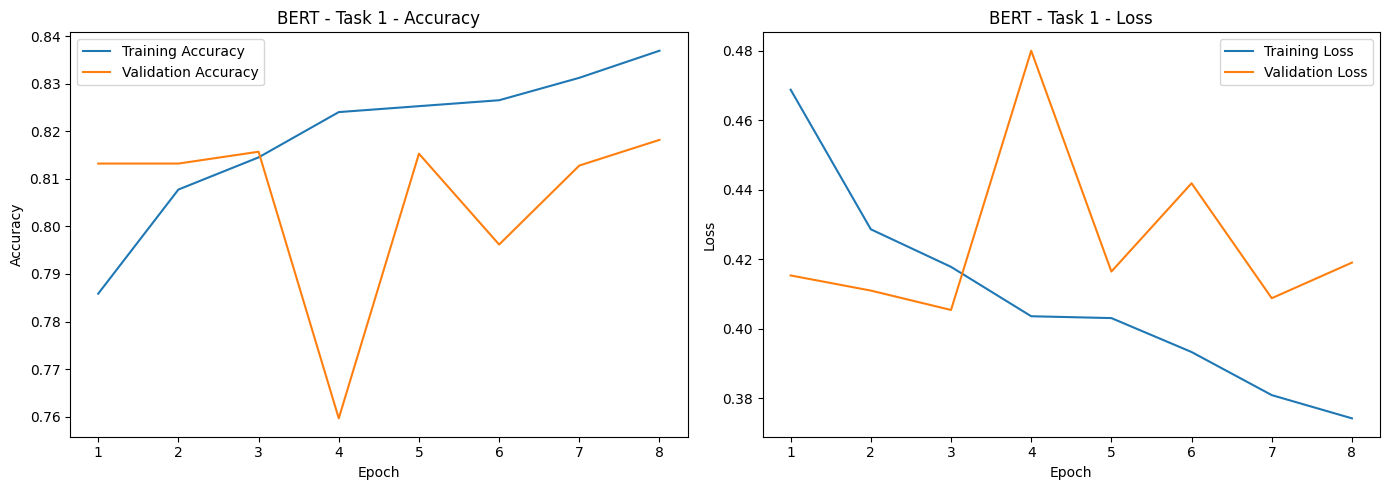

76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

📊 Results for BERT - Task 1
Accuracy : 0.8194
Precision: 0.7470
Recall   : 0.5490
F1-score : 0.6329


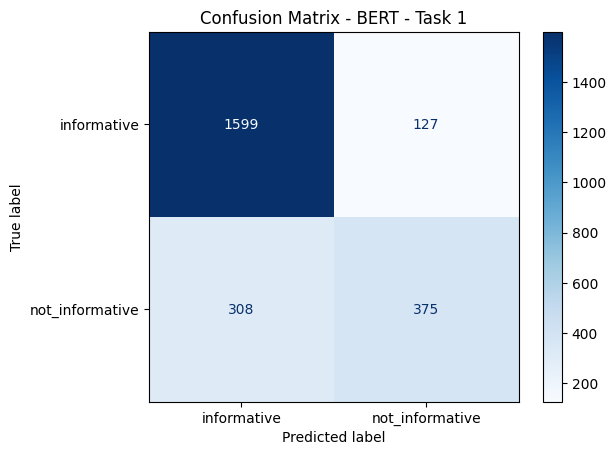


🚀 Training MLP on BERT embeddings (Task 2)
Epoch 1/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.5165 - loss: 1.2071 - val_accuracy: 0.5778 - val_loss: 1.0332
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6102 - loss: 0.9767 - val_accuracy: 0.6285 - val_loss: 0.9477
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6323 - loss: 0.9376 - val_accuracy: 0.6389 - val_loss: 0.9143
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6459 - loss: 0.8970 - val_accuracy: 0.6380 - val_loss: 0.9048
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6600 - loss: 0.8677 - val_accuracy: 0.6438 - val_loss: 0.8938
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6647 - loss: 0.8454 - val_accuracy: 0.6177 - val_loss: 0.9075
Epoch 7/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6731 - loss: 0.8262 - val_accuracy: 0.6343 - val_loss: 0.9106
Epoch 8/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accura

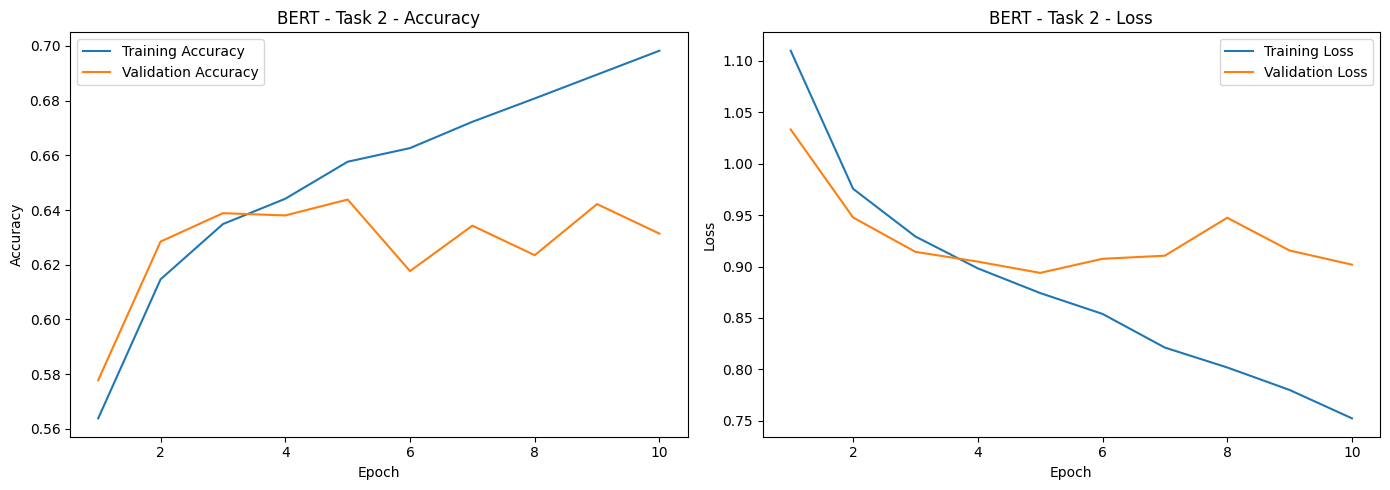

76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

📊 Results for BERT - Task 2
Accuracy : 0.6588
Precision: 0.6261
Recall   : 0.6166
F1-score : 0.6181


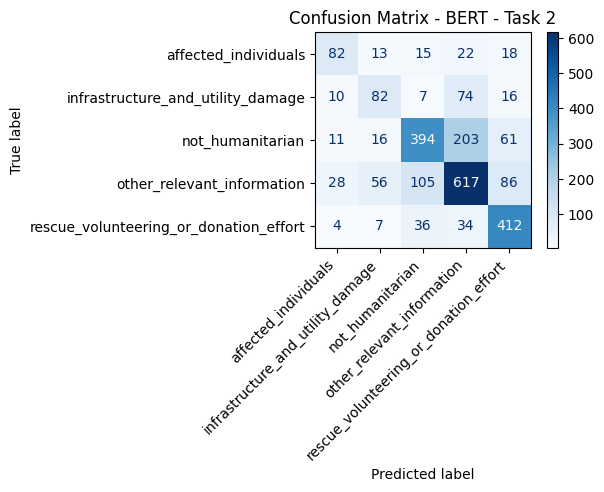

In [76]:
name = "bert"
X_train = embedding_sets[name]["train"]
X_val = embedding_sets[name]["val"]
X_test = embedding_sets[name]["test"]

# 🧪 Task 1: Informative vs Not informative (binario)
train_and_evaluate(name, X_train, train_labels_task1, X_val, val_labels_task1, X_test, test_labels_task1, task=1, label_encoder=le_info)

# 🧪 Task 2: Humanitarian categories (multiclasse)
train_and_evaluate(name, X_train, train_labels_task2, X_val, val_labels_task2, X_test, test_labels_task2, task=2, label_encoder=le_human)


🚀 Training MLP on ROBERTA embeddings (Task 1)
Epoch 1/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7604 - loss: 0.5209 - val_accuracy: 0.8232 - val_loss: 0.4064
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8219 - loss: 0.4152 - val_accuracy: 0.8261 - val_loss: 0.4095
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8158 - loss: 0.4198 - val_accuracy: 0.8219 - val_loss: 0.4013
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8176 - loss: 0.4173 - val_accuracy: 0.8215 - val_loss: 0.4041
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8216 - loss: 0.4081 - val_accuracy: 0.8182 - val_loss: 0.4063
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8347 - loss: 0.3899 - val_accuracy: 0.8298 - val_loss: 0.3928
Epoch 7/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8215 - loss: 0.3983 - val_accuracy: 0.8248 - val_loss: 0.4054
Epoch 8/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - acc

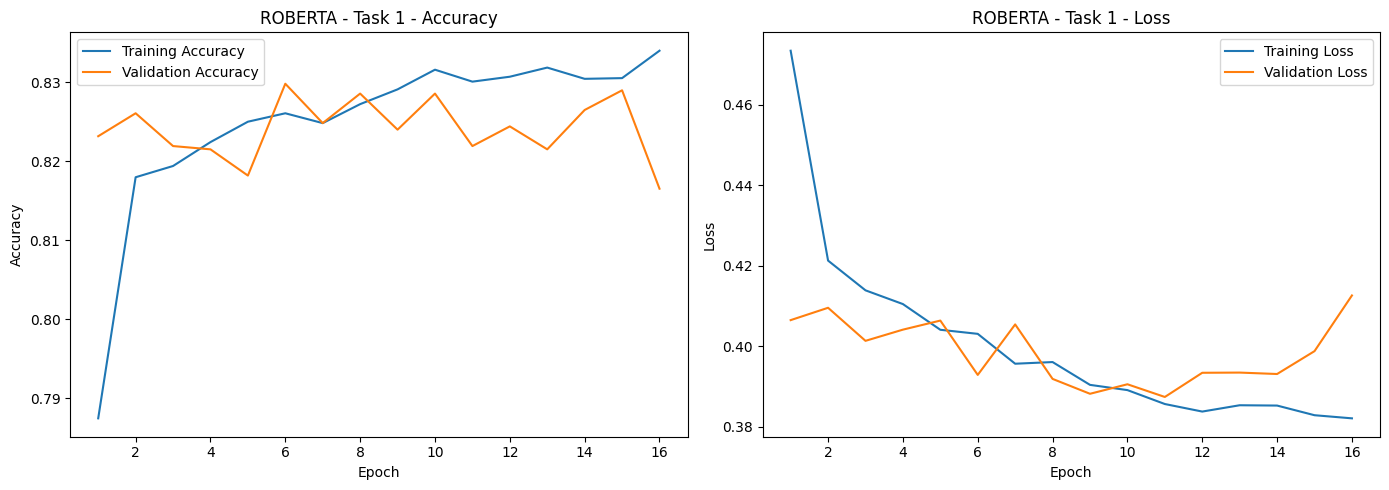

76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

📊 Results for ROBERTA - Task 1
Accuracy : 0.8269
Precision: 0.7409
Recall   : 0.5988
F1-score : 0.6623


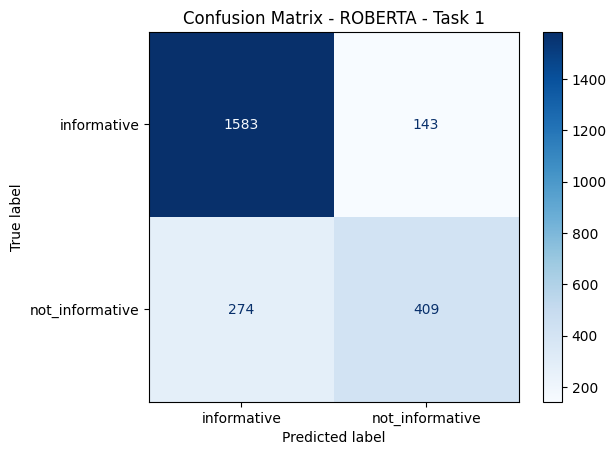


🚀 Training MLP on ROBERTA embeddings (Task 2)
Epoch 1/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.4593 - loss: 1.3028 - val_accuracy: 0.6214 - val_loss: 0.9554
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6223 - loss: 0.9730 - val_accuracy: 0.6459 - val_loss: 0.9013
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6435 - loss: 0.9157 - val_accuracy: 0.6687 - val_loss: 0.8630
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6472 - loss: 0.9002 - val_accuracy: 0.6467 - val_loss: 0.8930
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6547 - loss: 0.8723 - val_accuracy: 0.6629 - val_loss: 0.8449
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6659 - loss: 0.8501 - val_accuracy: 0.6633 - val_loss: 0.8393
Epoch 7/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6682 - loss: 0.8487 - val_accuracy: 0.6704 - val_loss: 0.8386
Epoch 8/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - acc

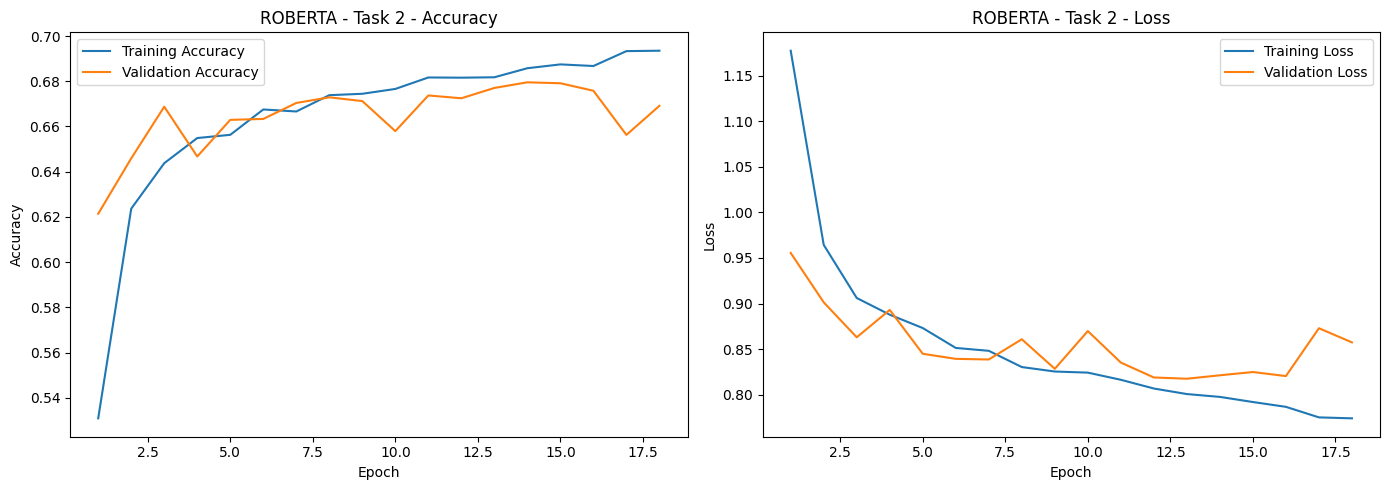

76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

📊 Results for ROBERTA - Task 2
Accuracy : 0.6907
Precision: 0.6669
Recall   : 0.6314
F1-score : 0.6406


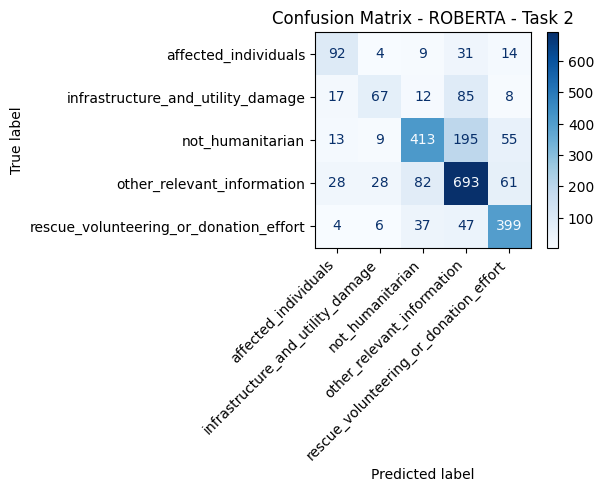

In [77]:
name = "roberta"
X_train = embedding_sets[name]["train"]
X_val = embedding_sets[name]["val"]
X_test = embedding_sets[name]["test"]

# 🧪 Task 1: Informative vs Not informative (binario)
train_and_evaluate(name, X_train, train_labels_task1, X_val, val_labels_task1, X_test, test_labels_task1, task=1,label_encoder=le_info)

# 🧪 Task 2: Humanitarian categories (multiclasse)
train_and_evaluate(name, X_train, train_labels_task2, X_val, val_labels_task2, X_test, test_labels_task2, task=2,label_encoder=le_human)


🚀 Training MLP on BERTWEET embeddings (Task 1)
Epoch 1/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7478 - loss: 0.5278 - val_accuracy: 0.8082 - val_loss: 0.4421
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8034 - loss: 0.4474 - val_accuracy: 0.7954 - val_loss: 0.4531
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7984 - loss: 0.4466 - val_accuracy: 0.8061 - val_loss: 0.4309
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8094 - loss: 0.4292 - val_accuracy: 0.8203 - val_loss: 0.4156
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8088 - loss: 0.4277 - val_accuracy: 0.8227 - val_loss: 0.4118
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8117 - loss: 0.4275 - val_accuracy: 0.8194 - val_loss: 0.4127
Epoch 7/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8126 - loss: 0.4159 - val_accuracy: 0.8215 - val_loss: 0.4121
Epoch 8/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - ac

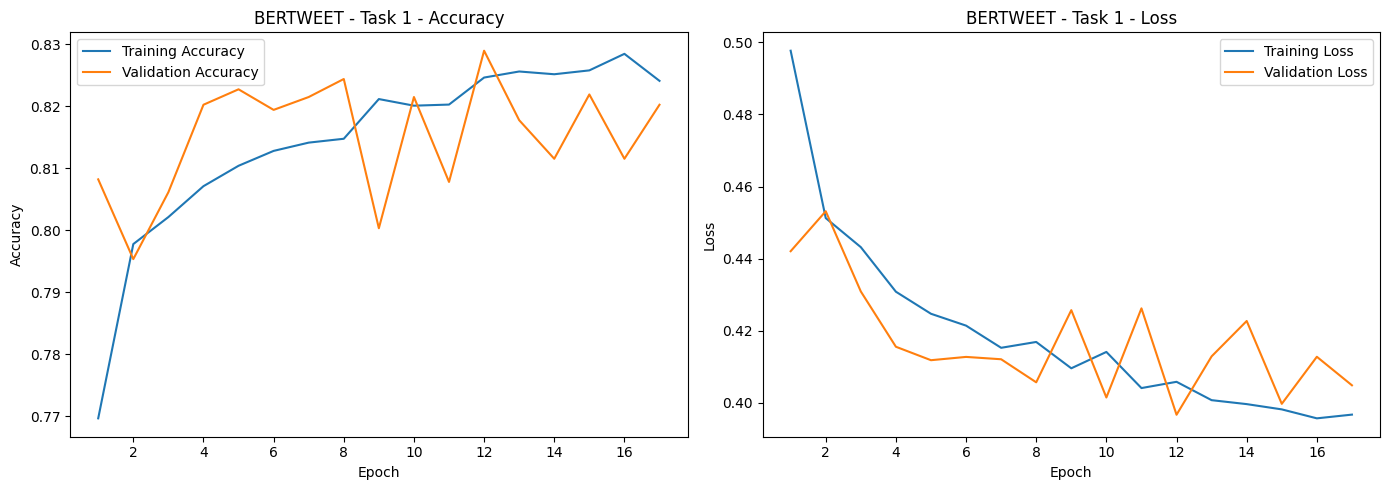

76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

📊 Results for BERTWEET - Task 1
Accuracy : 0.8182
Precision: 0.7360
Recall   : 0.5593
F1-score : 0.6356


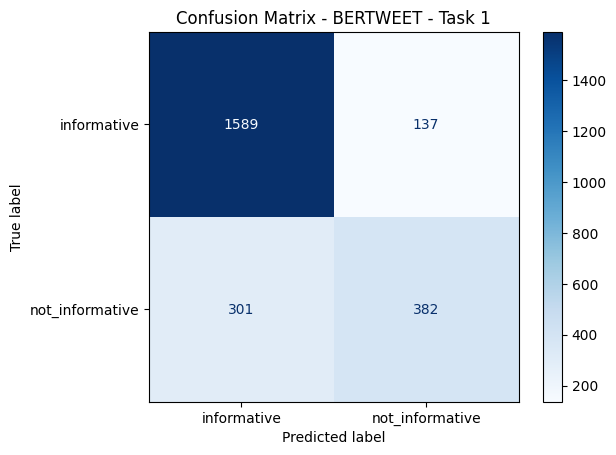


🚀 Training MLP on BERTWEET embeddings (Task 2)
Epoch 1/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.4641 - loss: 1.2950 - val_accuracy: 0.5795 - val_loss: 1.0271
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.5922 - loss: 1.0391 - val_accuracy: 0.6218 - val_loss: 0.9449
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6156 - loss: 0.9882 - val_accuracy: 0.6413 - val_loss: 0.9202
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6279 - loss: 0.9493 - val_accuracy: 0.6459 - val_loss: 0.9161
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6361 - loss: 0.9394 - val_accuracy: 0.6555 - val_loss: 0.8855
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6404 - loss: 0.9154 - val_accuracy: 0.6443 - val_loss: 0.9198
Epoch 7/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6348 - loss: 0.9150 - val_accuracy: 0.6633 - val_loss: 0.8576
Epoch 8/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - ac

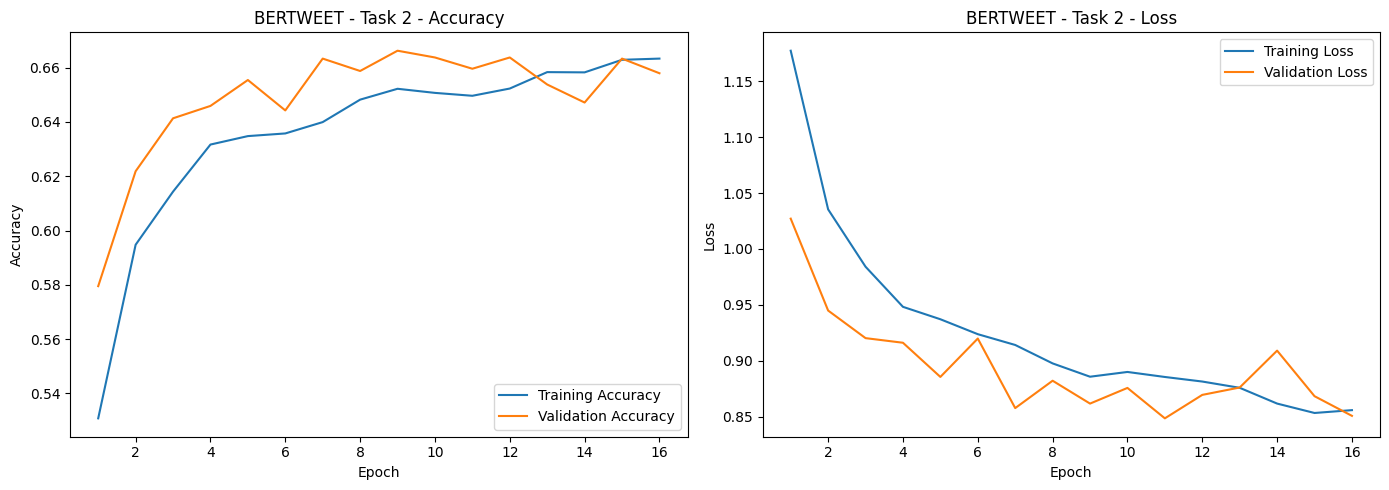

76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

📊 Results for BERTWEET - Task 2
Accuracy : 0.6795
Precision: 0.6881
Recall   : 0.6000
F1-score : 0.6284


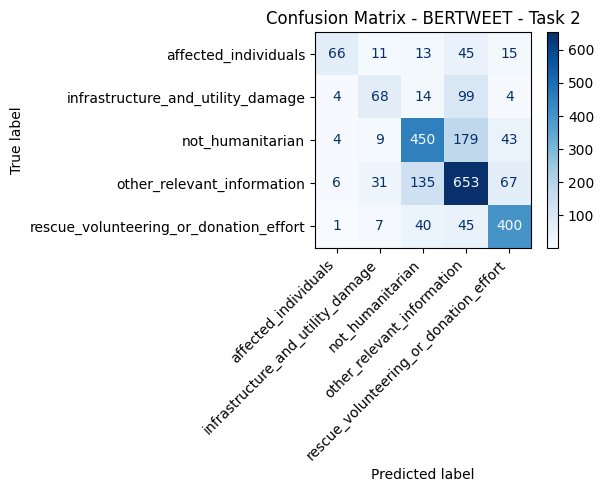

In [78]:
name = "bertweet"
X_train = embedding_sets[name]["train"]
X_val = embedding_sets[name]["val"]
X_test = embedding_sets[name]["test"]

# 🧪 Task 1: Informative vs Not informative (binario)
train_and_evaluate(name, X_train, train_labels_task1, X_val, val_labels_task1, X_test, test_labels_task1, task=1, label_encoder=le_info)

# 🧪 Task 2: Humanitarian categories (multiclasse)
train_and_evaluate(name, X_train, train_labels_task2, X_val, val_labels_task2, X_test, test_labels_task2, task=2, label_encoder=le_human)

## HuggingFace Models - Fine-Tuning

In [7]:
def compute_metrics(pred, is_binary=True):
    preds = np.argmax(pred.predictions, axis=1)
    labels = pred.label_ids
    avg_type = 'binary' if is_binary else 'macro'
    return {
        'accuracy': accuracy_score(labels, preds),
        'precision': precision_score(labels, preds, average=avg_type, zero_division=0),
        'recall': recall_score(labels, preds, average=avg_type, zero_division=0),
        'f1': f1_score(labels, preds, average=avg_type, zero_division=0),
    }

def plot_loss_curves(trainer):
    log_history = trainer.state.log_history

    epochs = []
    train_losses = []
    val_losses = []

    for entry in log_history:
        if "loss" in entry and "epoch" in entry:
            train_losses.append(entry["loss"])
            epochs.append(entry["epoch"])
        if "eval_loss" in entry:
            val_losses.append(entry["eval_loss"])

    plt.plot(epochs, train_losses, label="Training Loss")
    if val_losses:
        plt.plot(epochs, val_losses, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training vs Validation Loss")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Freeze primi `k` layer del modello transformer
def freeze_model_layers(model, num_freeze=6):
    try:
        # Per modelli BERT, RoBERTa, BERTweet
        encoder_layers = model.base_model.encoder.layer
        num_total_layers = len(encoder_layers)

        # Congela gli ULTIMI num_freeze layer
        for i in range(num_total_layers - num_freeze, num_total_layers):
            for param in encoder_layers[i].parameters():
                param.requires_grad = False
        print(f"✅ Congelati gli ultimi {num_freeze} layer.")

        # Sblocca anche la classification head
        if hasattr(model, "classifier"):
            for param in model.classifier.parameters():
                param.requires_grad = True
        elif hasattr(model, "score"):
            for param in model.score.parameters():
                param.requires_grad = True
        else:
            raise ValueError("Nessuna classification head trovata (classifier o score).")

    except AttributeError:
        print("⚠️ Impossibile accedere ai layer encoder: modello non standard.")


def train_transformer_model(model_name, df_train, df_val, df_test, text_column, label_column, 
                            num_labels, task_name, freeze_layers=0, label_encoder=None):
    """
    Esegue fine-tuning di un transformer Hugging Face per una classificazione testuale.

    Args:
        model_name (str): es. 'bert-base-uncased', 'vinai/bertweet-base'
        df_train, df_val, df_test (DataFrame): contengono testo e label
        text_column (str): nome colonna testo
        label_column (str): nome colonna label (interi)
        num_labels (int): 2 (binario) o N classi
        task_name (str): "Task 1" o "Task 2"
    """

    tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)

    # Tokenizzazione
    def tokenize_fn(examples):
        return tokenizer(examples[text_column], truncation=True, padding=True, max_length=128)

    # Conversione a Dataset Hugging Face
    ds_train = Dataset.from_pandas(df_train[[text_column, label_column]])
    ds_val = Dataset.from_pandas(df_val[[text_column, label_column]])
    ds_test = Dataset.from_pandas(df_test[[text_column, label_column]])

    ds_train = ds_train.rename_column(label_column, "label")
    ds_val = ds_val.rename_column(label_column, "label")
    ds_test = ds_test.rename_column(label_column, "label")

    ds_train = ds_train.map(tokenize_fn, batched=True)
    ds_val = ds_val.map(tokenize_fn, batched=True)
    ds_test = ds_test.map(tokenize_fn, batched=True)

    # Modello
    model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=num_labels)
    if freeze_layers > 0:
        freeze_model_layers(model, num_freeze=freeze_layers)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device) 
    
    # TrainingArguments
    training_args = TrainingArguments(
        output_dir="./results",
        logging_dir="./logs",
        logging_strategy="epoch",
        save_strategy="epoch",
        save_total_limit=1,
        eval_strategy="epoch",
        learning_rate=2e-5,
        per_device_train_batch_size=32,
        per_device_eval_batch_size=32,
        num_train_epochs=10,
        weight_decay=0.01,
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        fp16=True,
        report_to=[],
    )
    import logging
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=ds_train,
        eval_dataset=ds_val,
        compute_metrics=lambda p: compute_metrics(p, is_binary=(num_labels == 2)),
        tokenizer=tokenizer,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
    )

    # Training
    trainer.train()
    plot_loss_curves(trainer)
    
    # Valutazione su test set
    test_metrics = trainer.evaluate(ds_test)
    print(f"\n📊 Test metrics for {model_name} - {task_name}")
    for k, v in test_metrics.items():
        if k.startswith("eval_"):
            print(f"{k[5:]}: {v:.4f}")
    
    # Confusion Matrix
    preds_output = trainer.predict(ds_test)
    preds = np.argmax(preds_output.predictions, axis=1)
    labels = preds_output.label_ids

    # Classi leggibili per la confusion matrix
    if label_encoder is not None:
        class_names = label_encoder.classes_
    else:
        class_names = sorted(set(labels))  # fallback (numeri)

    # Plot
    cm = confusion_matrix(labels, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap='Blues')
    plt.title(f"{model_name} Confusion Matrix - {task_name}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()



In [8]:
text_train_df["text_info_encoded"] = train_labels_task1
text_val_df["text_info_encoded"] = val_labels_task1
text_test_df["text_info_encoded"] = test_labels_task1

text_train_df["text_human_encoded"] = train_labels_task2
text_val_df["text_human_encoded"] = val_labels_task2
text_test_df["text_human_encoded"] = test_labels_task2

text_train_df.head(5)

,tweet_text,text_info,text_human,cleaned_text_bert,cleaned_text_bertweet,text_info_encoded,text_human_encoded
0,Trucking Companies Houston's Lifeline Surges I...,informative,rescue_volunteering_or_donation_effort,Trucking Companies Houston's Lifeline Surges I...,Trucking Companies Houston's Lifeline Surges I...,0,4
1,#Hurricane #Harvey damaged #ExxonMobil refiner...,informative,infrastructure_and_utility_damage,Hurricane Harvey damaged ExxonMobil refineries...,#Hurricane #Harvey damaged #ExxonMobil refiner...,0,1
2,Witness in former Mora superintendent's forger...,not_informative,not_humanitarian,Witness in former Mora superintendent's forger...,Witness in former Mora superintendent's forger...,1,2
3,Mexico earthquake: Many children killed at pri...,informative,affected_individuals,Mexico earthquake: Many children killed at pri...,Mexico earthquake: Many children killed at pri...,0,0
4,@KrollOntrack is offering discounted recoverie...,informative,rescue_volunteering_or_donation_effort,is offering discounted recoveries for hurrican...,@KrollOntrack is offering discounted recoverie...,0,4


In [9]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

True
NVIDIA GeForce RTX 2060


## BERTWEET

### NO FREEZE

c:\Users\mario\Desktop\Deep Learning\Progetto\multimodal-crisis-classification\deep_env\lib\site-packages\huggingface_hub\file_download.py:943: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Map: 100%|██████████| 2409/2409 [00:01<00:00, 2148.91 examples/s]
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at vinai/bertweet-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
 10%|█         | 352/3520 [01:10<09:31,  5.54it/s]

{'loss': 0.4265, 'grad_norm': 19.74751091003418, 'learning_rate': 1.800568181818182e-05, 'epoch': 1.0}


                                                  
 10%|█         | 352/3520 [01:13<09:31,  5.54it/s]

{'eval_loss': 0.3922255039215088, 'eval_accuracy': 0.8484848484848485, 'eval_precision': 0.9035532994923858, 'eval_recall': 0.5212298682284041, 'eval_f1': 0.6610956360259982, 'eval_runtime': 3.1087, 'eval_samples_per_second': 774.925, 'eval_steps_per_second': 24.448, 'epoch': 1.0}


 20%|██        | 704/3520 [02:25<08:39,  5.42it/s]  

...

{'loss': 0.1466, 'grad_norm': 0.9746624231338501, 'learning_rate': 1.0017045454545456e-05, 'epoch': 5.0}


                                                   
 50%|█████     | 1760/3520 [06:06<05:07,  5.73it/s]

{'eval_loss': 0.5283777117729187, 'eval_accuracy': 0.8389373183893731, 'eval_precision': 0.7134587554269175, 'eval_recall': 0.7218155197657394, 'eval_f1': 0.7176128093158661, 'eval_runtime': 3.019, 'eval_samples_per_second': 797.953, 'eval_steps_per_second': 25.174, 'epoch': 5.0}


 50%|█████     | 1760/3520 [06:09<06:09,  4.76it/s]


{'train_runtime': 369.6289, 'train_samples_per_second': 304.089, 'train_steps_per_second': 9.523, 'train_loss': 0.272046050158414, 'epoch': 5.0}


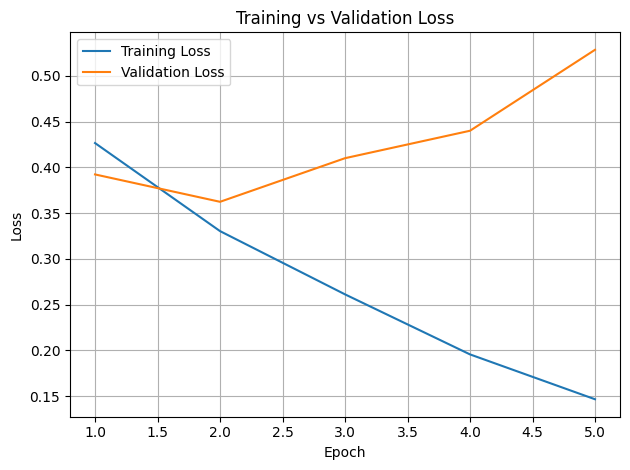

100%|██████████| 76/76 [00:03<00:00, 23.29it/s]



📊 Test metrics for vinai/bertweet-base - Task 1
loss: 0.4192
accuracy: 0.8306
precision: 0.8035
recall: 0.5329
f1: 0.6408
runtime: 3.3529
samples_per_second: 718.4800
steps_per_second: 22.6670


100%|██████████| 76/76 [00:03<00:00, 23.89it/s]


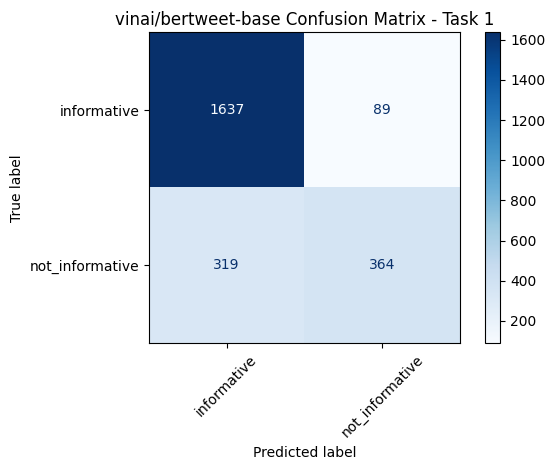

In [10]:
train_transformer_model(
    model_name="vinai/bertweet-base",
    df_train=text_train_df,
    df_val=text_val_df,
    df_test=text_test_df,
    text_column="tweet_text",
    label_column="text_info_encoded",  # già label encoder
    num_labels=text_train_df["text_info_encoded"].nunique(),
    task_name="Task 1",
    label_encoder=le_info
)

c:\Users\mario\Desktop\Deep Learning\Progetto\multimodal-crisis-classification\deep_env\lib\site-packages\huggingface_hub\file_download.py:943: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Map: 100%|██████████| 2409/2409 [00:01<00:00, 1904.30 examples/s]
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at vinai/bertweet-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
 10%|█         | 352/3520 [01:07<09:24,  5.61it/s]

{'loss': 0.9903, 'grad_norm': 14.76253604888916, 'learning_rate': 1.8022727272727275e-05, 'epoch': 1.0}



 10%|█         | 352/3520 [01:10<09:24,  5.61it/s]

{'eval_loss': 0.7694624662399292, 'eval_accuracy': 0.7189705271897052, 'eval_precision': 0.7034839909176505, 'eval_recall': 0.6898892582876661, 'eval_f1': 0.6890007066293548, 'eval_runtime': 3.032, 'eval_samples_per_second': 794.527, 'eval_steps_per_second': 25.066, 'epoch': 1.0}


 20%|██        | 704/3520 [02:20<08:07,  5.78it/s]  

...

{'loss': 0.3521, 'grad_norm': 25.728618621826172, 'learning_rate': 1.0022727272727272e-05, 'epoch': 5.0}



 50%|█████     | 1760/3520 [06:01<05:01,  5.84it/s]

{'eval_loss': 0.9373213052749634, 'eval_accuracy': 0.6990452469904525, 'eval_precision': 0.6770458850448158, 'eval_recall': 0.7082873627312394, 'eval_f1': 0.6862193767484827, 'eval_runtime': 3.0231, 'eval_samples_per_second': 796.876, 'eval_steps_per_second': 25.14, 'epoch': 5.0}


 50%|█████     | 1760/3520 [06:04<06:04,  4.83it/s]


{'train_runtime': 364.1586, 'train_samples_per_second': 308.657, 'train_steps_per_second': 9.666, 'train_loss': 0.6101952162655917, 'epoch': 5.0}


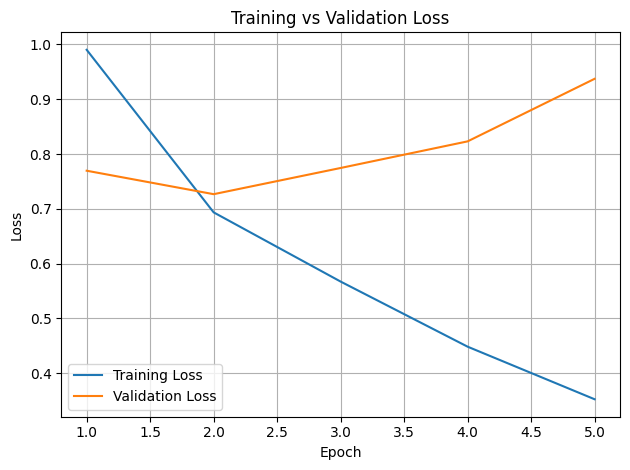

100%|██████████| 76/76 [00:03<00:00, 23.60it/s]



📊 Test metrics for vinai/bertweet-base - Task 2
loss: 0.7908
accuracy: 0.6953
precision: 0.6856
recall: 0.6555
f1: 0.6605
runtime: 3.3036
samples_per_second: 729.2000
steps_per_second: 23.0050


100%|██████████| 76/76 [00:03<00:00, 23.69it/s]


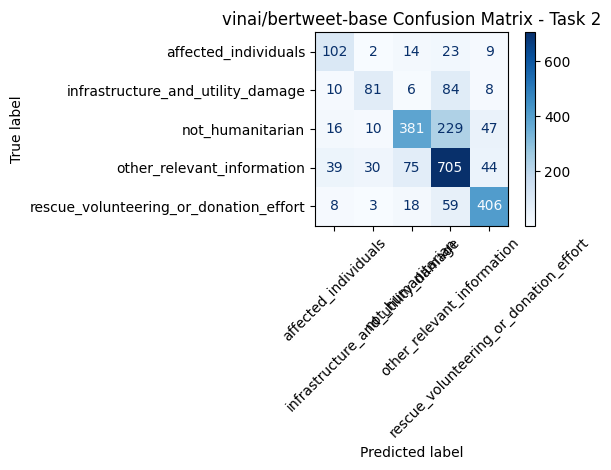

In [11]:
train_transformer_model(
    model_name="vinai/bertweet-base",
    df_train=text_train_df,
    df_val=text_val_df,
    df_test=text_test_df,
    text_column="tweet_text",
    label_column="text_human_encoded",  # già label encoder
    num_labels=text_train_df["text_human_encoded"].nunique(),
    task_name="Task 2",
    label_encoder = le_human
)

### FREEZING

In [12]:
model_name = "vinai/bertweet-base"
model = AutoModelForSequenceClassification.from_pretrained(model_name)

print("Numero totale layer:", len(model.base_model.encoder.layer))

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at vinai/bertweet-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Numero totale layer: 12


c:\Users\mario\Desktop\Deep Learning\Progetto\multimodal-crisis-classification\deep_env\lib\site-packages\huggingface_hub\file_download.py:943: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Map: 100%|██████████| 2409/2409 [00:01<00:00, 2185.96 examples/s]
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at vinai/bertweet-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✅ Congelati gli ultimi 10 layer.


 10%|█         | 352/3520 [00:49<07:48,  6.76it/s]

{'loss': 0.5084, 'grad_norm': 24.56226921081543, 'learning_rate': 1.8022727272727275e-05, 'epoch': 1.0}



 10%|█         | 352/3520 [00:52<07:48,  6.76it/s]

...

{'loss': 0.2402, 'grad_norm': 5.4530930519104, 'learning_rate': 8.028409090909092e-06, 'epoch': 6.0}



 60%|██████    | 2112/3520 [05:20<03:16,  7.18it/s]

{'eval_loss': 0.4454289376735687, 'eval_accuracy': 0.8368617683686177, 'eval_precision': 0.7995867768595041, 'eval_recall': 0.5666178623718887, 'eval_f1': 0.6632390745501285, 'eval_runtime': 2.9945, 'eval_samples_per_second': 804.488, 'eval_steps_per_second': 25.38, 'epoch': 6.0}


 60%|██████    | 2112/3520 [05:21<03:34,  6.56it/s]


{'train_runtime': 321.7577, 'train_samples_per_second': 349.331, 'train_steps_per_second': 10.94, 'train_loss': 0.3492160602049394, 'epoch': 6.0}


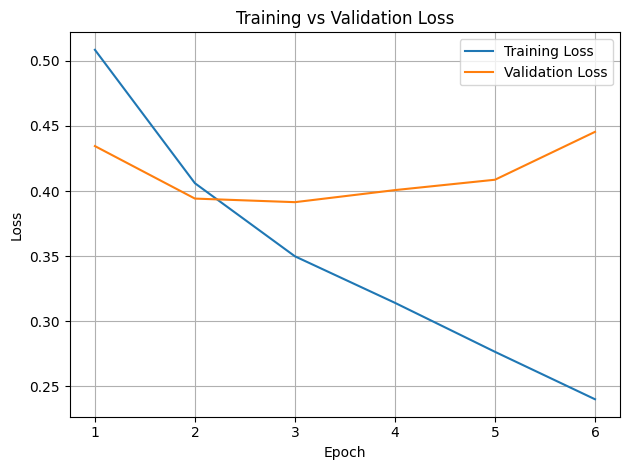

100%|██████████| 76/76 [00:03<00:00, 24.05it/s]



📊 Test metrics for vinai/bertweet-base - Task 1
loss: 0.4643
accuracy: 0.8182
precision: 0.7351
recall: 0.5608
f1: 0.6362
runtime: 3.2135
samples_per_second: 749.6520
steps_per_second: 23.6500


100%|██████████| 76/76 [00:03<00:00, 24.02it/s]


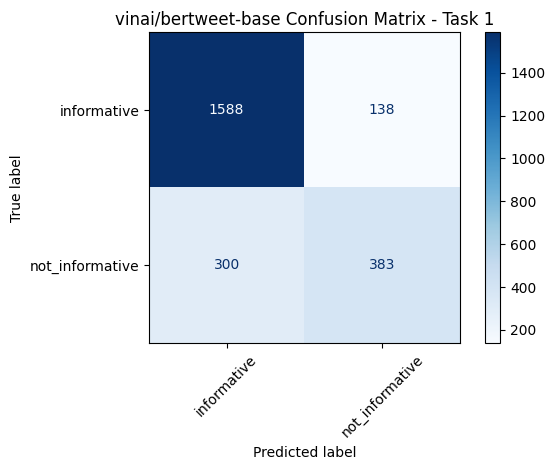

In [13]:
train_transformer_model(
    model_name="vinai/bertweet-base",
    df_train=text_train_df,
    df_val=text_val_df,
    df_test=text_test_df,
    text_column="tweet_text",
    label_column="text_info_encoded",  # già label encoder
    num_labels=text_train_df["text_info_encoded"].nunique(),
    task_name="Task 1",
    freeze_layers=10,
    label_encoder=le_info
)

c:\Users\mario\Desktop\Deep Learning\Progetto\multimodal-crisis-classification\deep_env\lib\site-packages\huggingface_hub\file_download.py:943: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Map: 100%|██████████| 2409/2409 [00:01<00:00, 2139.37 examples/s]
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at vinai/bertweet-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✅ Congelati gli ultimi 10 layer.


 10%|█         | 352/3520 [00:48<07:42,  6.86it/s]

{'loss': 1.4263, 'grad_norm': 7.929222583770752, 'learning_rate': 1.8051136363636366e-05, 'epoch': 1.0}



 10%|█         | 352/3520 [00:51<07:42,  6.86it/s]

...

{'loss': 0.5619, 'grad_norm': 10.850296974182129, 'learning_rate': 2.0511363636363636e-06, 'epoch': 9.0}



 90%|█████████ | 3168/3520 [07:55<00:48,  7.24it/s]

{'eval_loss': 0.9092928171157837, 'eval_accuracy': 0.6841012868410129, 'eval_precision': 0.6421613088574334, 'eval_recall': 0.63623734381419, 'eval_f1': 0.6367706100986643, 'eval_runtime': 2.9894, 'eval_samples_per_second': 805.853, 'eval_steps_per_second': 25.423, 'epoch': 9.0}


 90%|█████████ | 3168/3520 [07:57<00:53,  6.64it/s]


{'train_runtime': 477.0447, 'train_samples_per_second': 235.617, 'train_steps_per_second': 7.379, 'train_loss': 0.8447584672407671, 'epoch': 9.0}


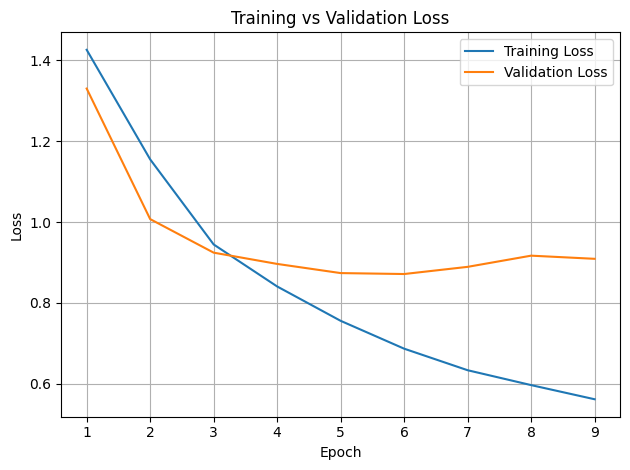

100%|██████████| 76/76 [00:03<00:00, 24.01it/s]



📊 Test metrics for vinai/bertweet-base - Task 2
loss: 0.9356
accuracy: 0.6575
precision: 0.6297
recall: 0.6139
f1: 0.6171
runtime: 3.2228
samples_per_second: 747.4770
steps_per_second: 23.5820


100%|██████████| 76/76 [00:03<00:00, 24.28it/s]


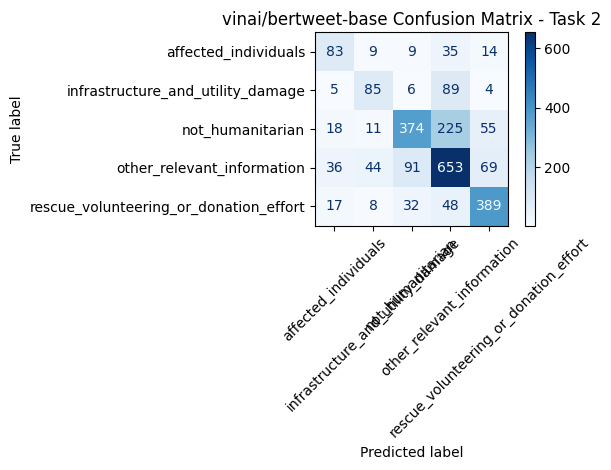

In [14]:
train_transformer_model(
    model_name="vinai/bertweet-base",
    df_train=text_train_df,
    df_val=text_val_df,
    df_test=text_test_df,
    text_column="tweet_text",
    label_column="text_human_encoded",  # già label encoder
    num_labels=text_train_df["text_human_encoded"].nunique(),
    task_name="Task 2",
    freeze_layers=10,
    label_encoder=le_human
)

## BERT CLASSICO

### NO FREEZE

Map: 100%|██████████| 2409/2409 [00:00<00:00, 11203.03 examples/s]
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
 10%|█         | 352/3520 [00:56<07:36,  6.94it/s]

{'loss': 0.4211, 'grad_norm': 19.359241485595703, 'learning_rate': 1.800568181818182e-05, 'epoch': 1.0}



 10%|█         | 352/3520 [00:59<07:36,  6.94it/s]

{'eval_loss': 0.4025498926639557, 'eval_accuracy': 0.8389373183893731, 'eval_precision': 0.9178470254957507, 'eval_recall': 0.4743777452415813, 'eval_f1': 0.6254826254826255, 'eval_runtime': 2.9985, 'eval_samples_per_second': 803.405, 'eval_steps_per_second': 25.346, 'epoch': 1.0}


 20%|██        | 704/3520 [01:57<06:37,  7.08it/s]  

...

{'loss': 0.0886, 'grad_norm': 0.1893187314271927, 'learning_rate': 1.0005681818181819e-05, 'epoch': 5.0}



 50%|█████     | 1760/3520 [05:03<04:41,  6.25it/s]

{'eval_loss': 0.656624972820282, 'eval_accuracy': 0.8376919883769199, 'eval_precision': 0.7693726937269373, 'eval_recall': 0.6105417276720352, 'eval_f1': 0.6808163265306122, 'eval_runtime': 3.0574, 'eval_samples_per_second': 787.912, 'eval_steps_per_second': 24.857, 'epoch': 5.0}


 50%|█████     | 1760/3520 [05:05<05:05,  5.77it/s]


{'train_runtime': 305.0263, 'train_samples_per_second': 368.493, 'train_steps_per_second': 11.54, 'train_loss': 0.24191915772177958, 'epoch': 5.0}


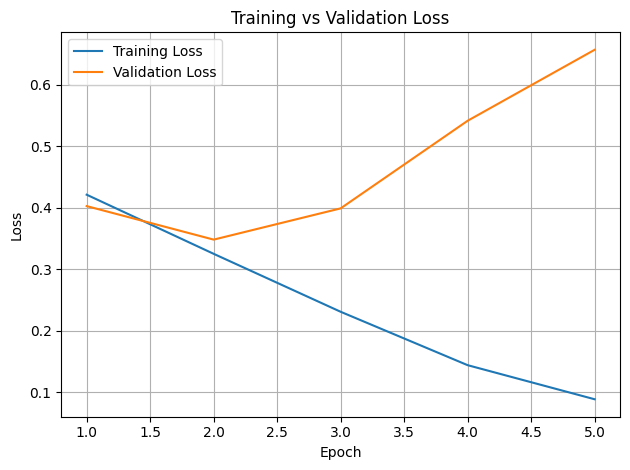

100%|██████████| 76/76 [00:03<00:00, 23.62it/s]



📊 Test metrics for bert-base-uncased - Task 1
loss: 0.4136
accuracy: 0.8319
precision: 0.7825
recall: 0.5637
f1: 0.6553
runtime: 3.2973
samples_per_second: 730.6010
steps_per_second: 23.0490


100%|██████████| 76/76 [00:03<00:00, 24.06it/s]


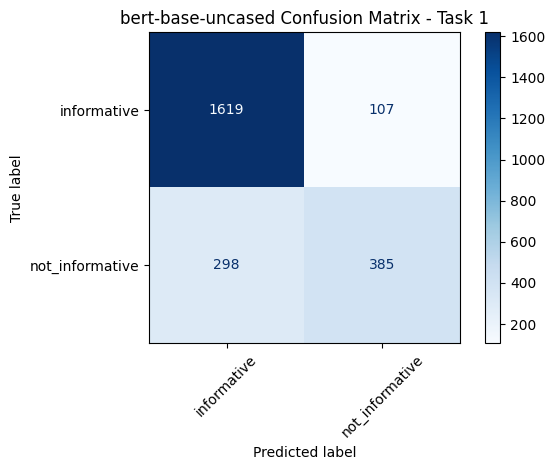

In [15]:
train_transformer_model(
    model_name="bert-base-uncased",
    df_train=text_train_df,
    df_val=text_val_df,
    df_test=text_test_df,
    text_column="tweet_text",
    label_column="text_info_encoded",  # già label encoder
    num_labels=text_train_df["text_info_encoded"].nunique(),
    task_name="Task 1",
    label_encoder=le_info
)

Map: 100%|██████████| 2409/2409 [00:00<00:00, 11471.45 examples/s]
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
 10%|█         | 352/3520 [00:56<08:21,  6.31it/s]

{'loss': 0.9334, 'grad_norm': 16.076539993286133, 'learning_rate': 1.8e-05, 'epoch': 1.0}



 10%|█         | 352/3520 [00:59<08:21,  6.31it/s]

{'eval_loss': 0.7625486254692078, 'eval_accuracy': 0.7177251971772519, 'eval_precision': 0.7139394569315632, 'eval_recall': 0.7039084088607742, 'eval_f1': 0.7012724148760229, 'eval_runtime': 3.0116, 'eval_samples_per_second': 799.907, 'eval_steps_per_second': 25.236, 'epoch': 1.0}


 20%|██        | 704/3520 [01:57<06:40,  7.04it/s]  

...

{'loss': 0.2186, 'grad_norm': 25.162534713745117, 'learning_rate': 1.0011363636363638e-05, 'epoch': 5.0}



 50%|█████     | 1760/3520 [05:02<04:11,  6.99it/s]

{'eval_loss': 1.0091570615768433, 'eval_accuracy': 0.7135740971357409, 'eval_precision': 0.706618473024156, 'eval_recall': 0.683372882905972, 'eval_f1': 0.6920317868412873, 'eval_runtime': 3.0177, 'eval_samples_per_second': 798.293, 'eval_steps_per_second': 25.185, 'epoch': 5.0}


 50%|█████     | 1760/3520 [05:04<05:04,  5.79it/s]


{'train_runtime': 304.0635, 'train_samples_per_second': 369.66, 'train_steps_per_second': 11.577, 'train_loss': 0.5205852898684415, 'epoch': 5.0}


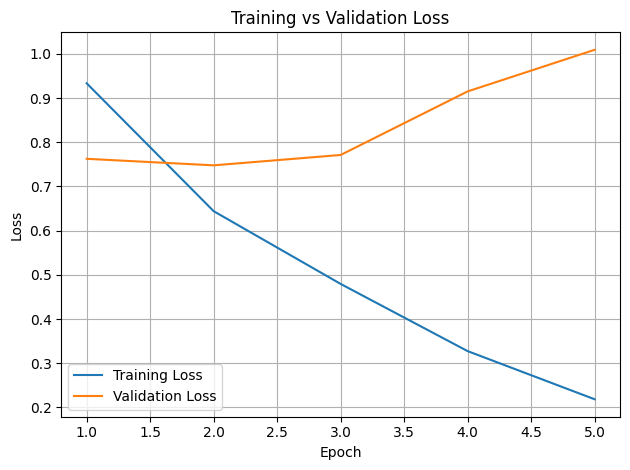

100%|██████████| 76/76 [00:03<00:00, 23.96it/s]



📊 Test metrics for bert-base-uncased - Task 2
loss: 0.8147
accuracy: 0.6982
precision: 0.6845
recall: 0.6640
f1: 0.6661
runtime: 3.2295
samples_per_second: 745.9300
steps_per_second: 23.5330


100%|██████████| 76/76 [00:03<00:00, 24.09it/s]


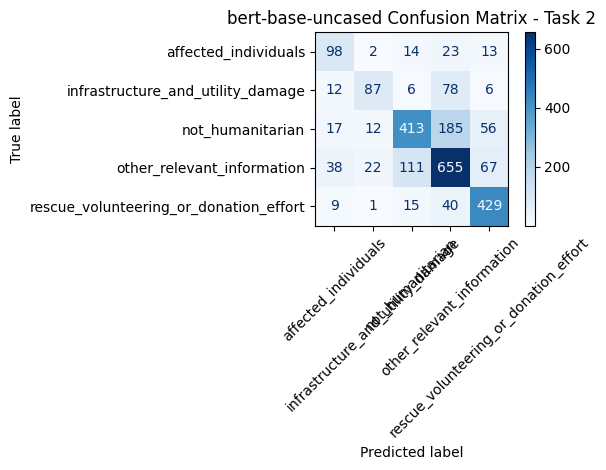

In [16]:
train_transformer_model(
    model_name="bert-base-uncased",
    df_train=text_train_df,
    df_val=text_val_df,
    df_test=text_test_df,
    text_column="tweet_text",
    label_column="text_human_encoded",  # già label encoder
    num_labels=text_train_df["text_human_encoded"].nunique(),
    task_name="Task 2",
    label_encoder=le_human
)

### FREEZING

In [17]:
model_name = "bert-base-uncased"
model = AutoModelForSequenceClassification.from_pretrained(model_name)

print("Numero totale layer:", len(model.base_model.encoder.layer))

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Numero totale layer: 12


Map: 100%|██████████| 2409/2409 [00:00<00:00, 11417.50 examples/s]
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✅ Congelati gli ultimi 10 layer.


 10%|█         | 352/3520 [00:37<05:43,  9.23it/s]

{'loss': 0.4841, 'grad_norm': 31.33640480041504, 'learning_rate': 1.8011363636363636e-05, 'epoch': 1.0}



 10%|█         | 352/3520 [00:41<05:43,  9.23it/s]

...

{'loss': 0.262, 'grad_norm': 6.973844528198242, 'learning_rate': 1.0011363636363638e-05, 'epoch': 5.0}



 50%|█████     | 1760/3520 [03:28<03:07,  9.36it/s]

{'eval_loss': 0.4081783592700958, 'eval_accuracy': 0.8414279784142797, 'eval_precision': 0.7761467889908257, 'eval_recall': 0.6193265007320644, 'eval_f1': 0.6889250814332247, 'eval_runtime': 3.0206, 'eval_samples_per_second': 797.531, 'eval_steps_per_second': 25.161, 'epoch': 5.0}


 50%|█████     | 1760/3520 [03:29<03:29,  8.41it/s]


{'train_runtime': 209.2089, 'train_samples_per_second': 537.262, 'train_steps_per_second': 16.825, 'train_loss': 0.3514413660222834, 'epoch': 5.0}


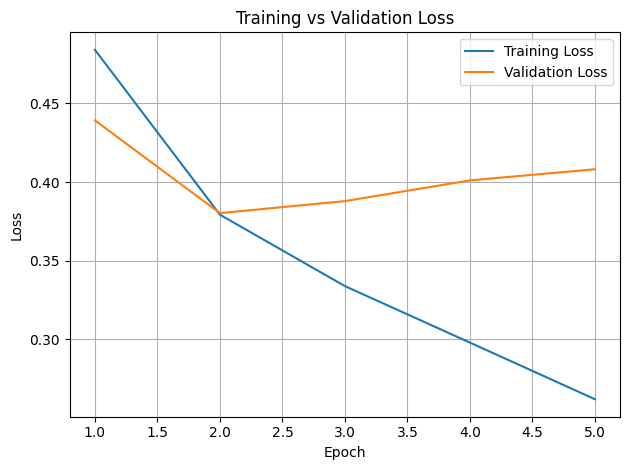

100%|██████████| 76/76 [00:03<00:00, 24.13it/s]



📊 Test metrics for bert-base-uncased - Task 1
loss: 0.4388
accuracy: 0.8165
precision: 0.7757
recall: 0.4963
f1: 0.6054
runtime: 3.2010
samples_per_second: 752.5850
steps_per_second: 23.7430


100%|██████████| 76/76 [00:03<00:00, 24.17it/s]


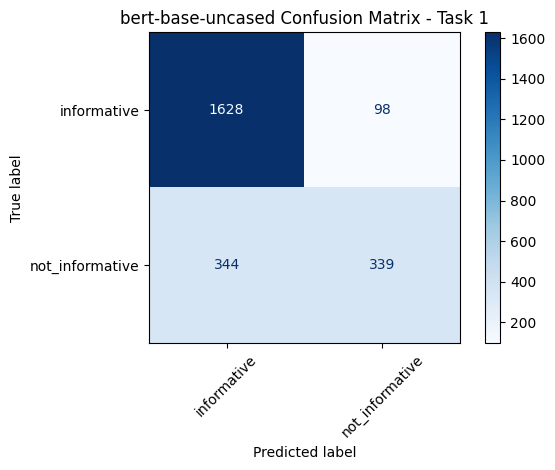

In [18]:
train_transformer_model(
    model_name="bert-base-uncased",
    df_train=text_train_df,
    df_val=text_val_df,
    df_test=text_test_df,
    text_column="tweet_text",
    label_column="text_info_encoded",  # già label encoder
    num_labels=text_train_df["text_info_encoded"].nunique(),
    task_name="Task 1",
    freeze_layers=10,
    label_encoder=le_info
)

Map: 100%|██████████| 2409/2409 [00:00<00:00, 11746.78 examples/s]
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✅ Congelati gli ultimi 10 layer.


 10%|█         | 352/3520 [00:38<05:37,  9.38it/s]

{'loss': 1.1907, 'grad_norm': inf, 'learning_rate': 1.800568181818182e-05, 'epoch': 1.0}



 10%|█         | 352/3520 [00:41<05:37,  9.38it/s]

...

{'loss': 0.4801, 'grad_norm': 11.1655855178833, 'learning_rate': 6.0113636363636376e-06, 'epoch': 7.0}



 70%|███████   | 2464/3520 [04:52<01:52,  9.39it/s]

{'eval_loss': 0.9257546067237854, 'eval_accuracy': 0.696969696969697, 'eval_precision': 0.6727521599497092, 'eval_recall': 0.6835762120034655, 'eval_f1': 0.6717358739269308, 'eval_runtime': 3.0078, 'eval_samples_per_second': 800.93, 'eval_steps_per_second': 25.268, 'epoch': 7.0}


 70%|███████   | 2464/3520 [04:53<02:05,  8.40it/s]


{'train_runtime': 293.2161, 'train_samples_per_second': 383.335, 'train_steps_per_second': 12.005, 'train_loss': 0.7251161909722662, 'epoch': 7.0}


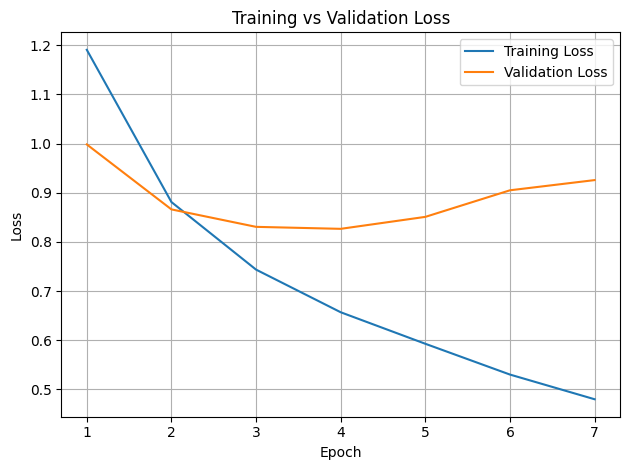

100%|██████████| 76/76 [00:03<00:00, 24.01it/s]



📊 Test metrics for bert-base-uncased - Task 2
loss: 0.8908
accuracy: 0.6804
precision: 0.6765
recall: 0.6311
f1: 0.6420
runtime: 3.2248
samples_per_second: 747.0220
steps_per_second: 23.5670


100%|██████████| 76/76 [00:03<00:00, 24.12it/s]


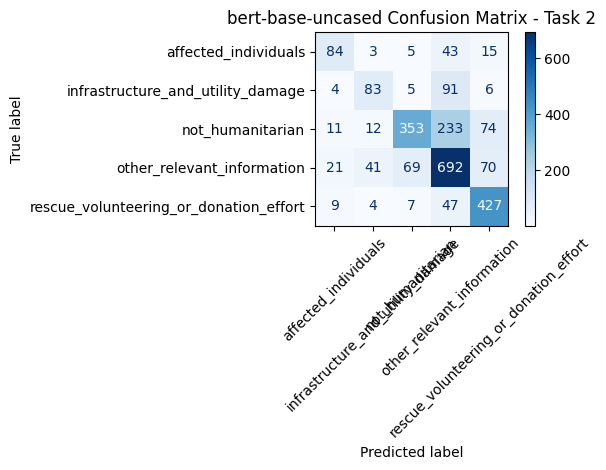

In [19]:
train_transformer_model(
    model_name="bert-base-uncased",
    df_train=text_train_df,
    df_val=text_val_df,
    df_test=text_test_df,
    text_column="tweet_text",
    label_column="text_human_encoded",  # già label encoder
    num_labels=text_train_df["text_human_encoded"].nunique(),
    task_name="Task 2",
    freeze_layers=10,
    label_encoder=le_human
)

## ROBERTA

### NO FREEZE

Map: 100%|██████████| 2409/2409 [00:00<00:00, 14014.02 examples/s]
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
 10%|█         | 352/3520 [01:25<10:05,  5.23it/s]  

{'loss': 0.4191, 'grad_norm': 31.697364807128906, 'learning_rate': 1.8011363636363636e-05, 'epoch': 1.0}



 10%|█         | 352/3520 [01:28<10:05,  5.23it/s]

{'eval_loss': 0.41770994663238525, 'eval_accuracy': 0.842673308426733, 'eval_precision': 0.9153005464480874, 'eval_recall': 0.4904831625183016, 'eval_f1': 0.6387035271687321, 'eval_runtime': 3.6861, 'eval_samples_per_second': 653.541, 'eval_steps_per_second': 20.618, 'epoch': 1.0}


 20%|██        | 704/3520 [02:49<08:57,  5.24it/s]  

...


 50%|█████     | 1760/3520 [07:03<05:39,  5.19it/s]

{'eval_loss': 0.5784448981285095, 'eval_accuracy': 0.8476546284765463, 'eval_precision': 0.7851985559566786, 'eval_recall': 0.636896046852123, 'eval_f1': 0.7033144704931286, 'eval_runtime': 3.7151, 'eval_samples_per_second': 648.432, 'eval_steps_per_second': 20.457, 'epoch': 5.0}


 50%|█████     | 1760/3520 [07:06<05:39,  5.19it/s]

{'train_runtime': 426.1628, 'train_samples_per_second': 263.749, 'train_steps_per_second': 8.26, 'train_loss': 0.2699908104809848, 'epoch': 5.0}


 50%|█████     | 1760/3520 [07:06<07:06,  4.13it/s]


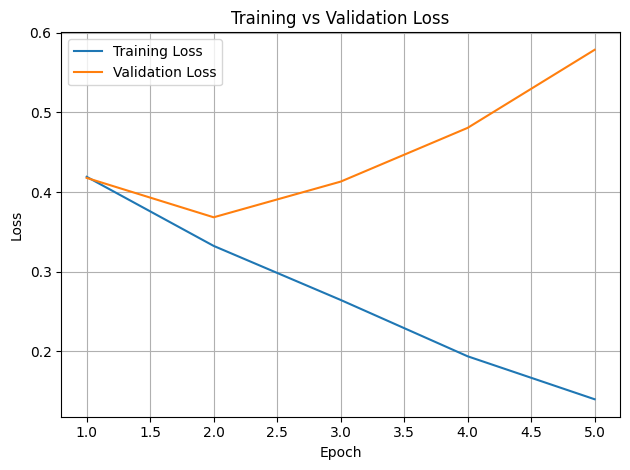

100%|██████████| 76/76 [00:04<00:00, 17.40it/s]



📊 Test metrics for roberta-base - Task 1
loss: 0.4288
accuracy: 0.8294
precision: 0.8077
recall: 0.5227
f1: 0.6347
runtime: 4.4932
samples_per_second: 536.1380
steps_per_second: 16.9140


100%|██████████| 76/76 [00:04<00:00, 17.65it/s]


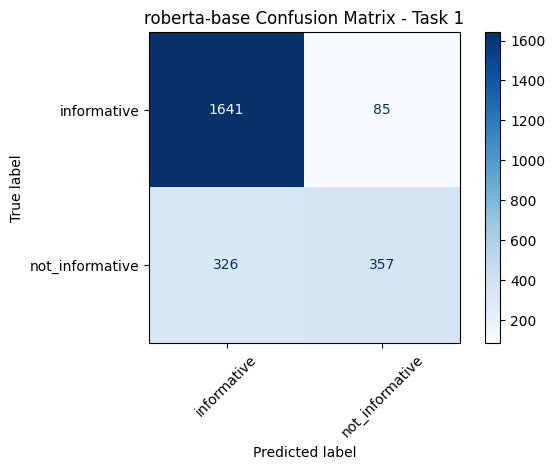

In [20]:
train_transformer_model(
    model_name="roberta-base",
    df_train=text_train_df,
    df_val=text_val_df,
    df_test=text_test_df,
    text_column="tweet_text",
    label_column="text_info_encoded",  # già label encoder
    num_labels=text_train_df["text_info_encoded"].nunique(),
    task_name="Task 1",
    label_encoder=le_info
)

Map: 100%|██████████| 2409/2409 [00:00<00:00, 13844.58 examples/s]
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
 10%|█         | 352/3520 [01:18<10:05,  5.23it/s]

{'loss': 0.914, 'grad_norm': 21.00330352783203, 'learning_rate': 1.8011363636363636e-05, 'epoch': 1.0}



 10%|█         | 352/3520 [01:22<10:05,  5.23it/s]

{'eval_loss': 0.7667644023895264, 'eval_accuracy': 0.7131589871315899, 'eval_precision': 0.7197496613746865, 'eval_recall': 0.6896105372381331, 'eval_f1': 0.6935571972137737, 'eval_runtime': 3.6645, 'eval_samples_per_second': 657.395, 'eval_steps_per_second': 20.74, 'epoch': 1.0}


 20%|██        | 704/3520 [02:42<09:01,  5.20it/s]  

...


 50%|█████     | 1760/3520 [06:57<05:33,  5.28it/s]

{'eval_loss': 0.8698445558547974, 'eval_accuracy': 0.7272727272727273, 'eval_precision': 0.7036915790462074, 'eval_recall': 0.720413278453371, 'eval_f1': 0.7088838559092705, 'eval_runtime': 3.6782, 'eval_samples_per_second': 654.934, 'eval_steps_per_second': 20.662, 'epoch': 5.0}


 50%|█████     | 1760/3520 [07:00<05:33,  5.28it/s]

{'train_runtime': 420.2439, 'train_samples_per_second': 267.464, 'train_steps_per_second': 8.376, 'train_loss': 0.5848979646509344, 'epoch': 5.0}


 50%|█████     | 1760/3520 [07:00<07:00,  4.19it/s]


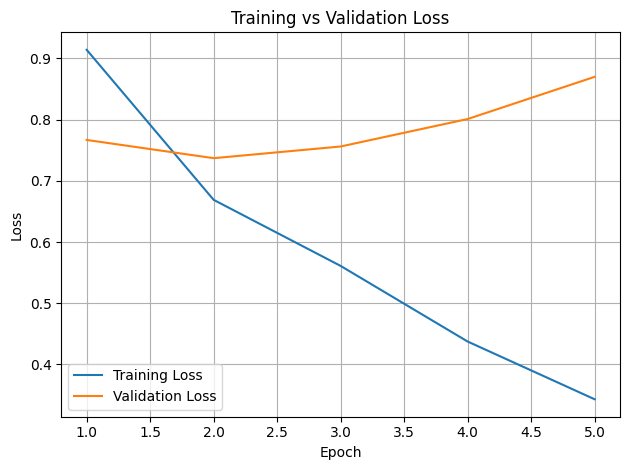

100%|██████████| 76/76 [00:04<00:00, 17.47it/s]



📊 Test metrics for roberta-base - Task 2
loss: 0.7796
accuracy: 0.7007
precision: 0.6959
recall: 0.6780
f1: 0.6771
runtime: 4.4946
samples_per_second: 535.9730
steps_per_second: 16.9090


100%|██████████| 76/76 [00:04<00:00, 17.77it/s]


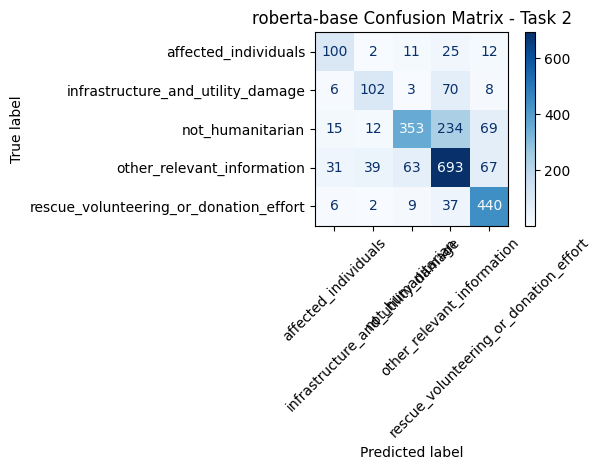

In [21]:
train_transformer_model(
    model_name="roberta-base",
    df_train=text_train_df,
    df_val=text_val_df,
    df_test=text_test_df,
    text_column="tweet_text",
    label_column="text_human_encoded",  # già label encoder
    num_labels=text_train_df["text_human_encoded"].nunique(),
    task_name="Task 2",
    label_encoder=le_human
)

### FREEZING

In [22]:
model_name = "roberta-base"
model = AutoModelForSequenceClassification.from_pretrained(model_name)

print("Numero totale layer:", len(model.base_model.encoder.layer))

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Numero totale layer: 12


Map: 100%|██████████| 2409/2409 [00:00<00:00, 13765.74 examples/s]
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✅ Congelati gli ultimi 10 layer.


 10%|█         | 352/3520 [00:56<08:26,  6.25it/s]

{'loss': 0.528, 'grad_norm': 10.017836570739746, 'learning_rate': 1.8e-05, 'epoch': 1.0}



 10%|█         | 352/3520 [01:00<08:26,  6.25it/s]

...

{'loss': 0.2604, 'grad_norm': 4.979643821716309, 'learning_rate': 6.0113636363636376e-06, 'epoch': 7.0}



 70%|███████   | 2464/3520 [07:10<02:49,  6.23it/s]

{'eval_loss': 0.43788623809814453, 'eval_accuracy': 0.8393524283935243, 'eval_precision': 0.769090909090909, 'eval_recall': 0.6193265007320644, 'eval_f1': 0.6861313868613139, 'eval_runtime': 3.6719, 'eval_samples_per_second': 656.063, 'eval_steps_per_second': 20.698, 'epoch': 7.0}


 70%|███████   | 2464/3520 [07:12<03:05,  5.70it/s]


{'train_runtime': 432.5113, 'train_samples_per_second': 259.878, 'train_steps_per_second': 8.139, 'train_loss': 0.3544891592744109, 'epoch': 7.0}


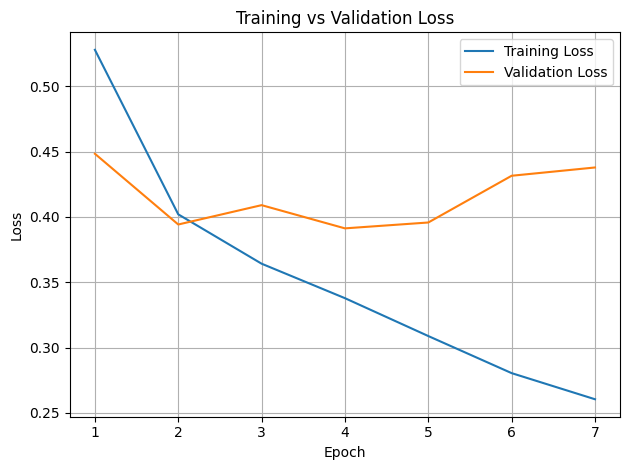

100%|██████████| 76/76 [00:04<00:00, 17.68it/s]



📊 Test metrics for roberta-base - Task 1
loss: 0.4328
accuracy: 0.8257
precision: 0.7955
recall: 0.5183
f1: 0.6277
runtime: 4.3621
samples_per_second: 552.2570
steps_per_second: 17.4230


100%|██████████| 76/76 [00:04<00:00, 17.77it/s]


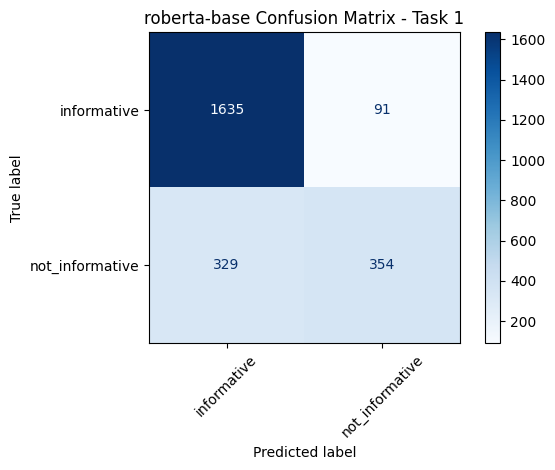

In [23]:
train_transformer_model(
    model_name="roberta-base",
    df_train=text_train_df,
    df_val=text_val_df,
    df_test=text_test_df,
    text_column="tweet_text",
    label_column="text_info_encoded",  # già label encoder
    num_labels=text_train_df["text_info_encoded"].nunique(),
    task_name="Task 1",
    freeze_layers=10,
    label_encoder=le_info
)

Map: 100%|██████████| 2409/2409 [00:00<00:00, 13684.27 examples/s]
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✅ Congelati gli ultimi 10 layer.


 10%|█         | 352/3520 [00:57<08:30,  6.21it/s]

{'loss': 1.3938, 'grad_norm': inf, 'learning_rate': 1.800568181818182e-05, 'epoch': 1.0}



 10%|█         | 352/3520 [01:00<08:30,  6.21it/s]

...

{'loss': 0.6413, 'grad_norm': 12.373161315917969, 'learning_rate': 8.00568181818182e-06, 'epoch': 6.0}



 60%|██████    | 2112/3520 [06:12<03:46,  6.20it/s]

{'eval_loss': 0.8545230031013489, 'eval_accuracy': 0.6774595267745953, 'eval_precision': 0.6420461460446247, 'eval_recall': 0.6704413136172911, 'eval_f1': 0.6525345933222695, 'eval_runtime': 3.6739, 'eval_samples_per_second': 655.715, 'eval_steps_per_second': 20.687, 'epoch': 6.0}


 60%|██████    | 2112/3520 [06:13<04:09,  5.65it/s]


{'train_runtime': 373.7729, 'train_samples_per_second': 300.717, 'train_steps_per_second': 9.417, 'train_loss': 0.8707910306525953, 'epoch': 6.0}


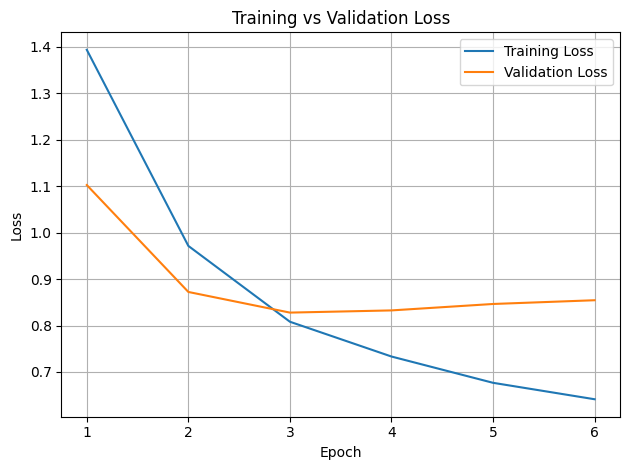

100%|██████████| 76/76 [00:04<00:00, 17.64it/s]



📊 Test metrics for roberta-base - Task 2
loss: 0.8551
accuracy: 0.6800
precision: 0.6581
recall: 0.6423
f1: 0.6454
runtime: 4.3839
samples_per_second: 549.5060
steps_per_second: 17.3360


100%|██████████| 76/76 [00:04<00:00, 17.74it/s]


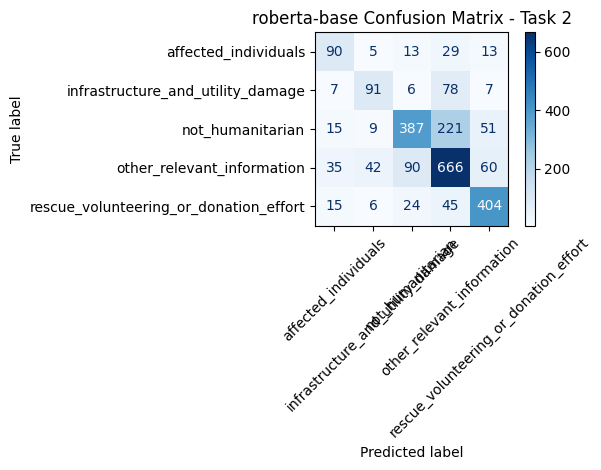

In [24]:
train_transformer_model(
    model_name="roberta-base",
    df_train=text_train_df,
    df_val=text_val_df,
    df_test=text_test_df,
    text_column="tweet_text",
    label_column="text_human_encoded",  # già label encoder
    num_labels=text_train_df["text_human_encoded"].nunique(),
    task_name="Task 2",
    freeze_layers=10,
    label_encoder=le_human
)